# 🌾 Crop Recommendation — Confidence Boost to 70%+

## Why confidence is still low at 56%

| Root Cause | Explanation |
|---|---|
| **Too many classes** | 51 crops → RF probability is spread thin across all classes |
| **Ambiguous sample** | `[90,40,40,25,80,6.5,200]` sits where multiple crops overlap in feature space |
| **RF is a flat probability estimator** | Each tree votes 1 class → average stays low when trees disagree |
| **Isotonic calibration hurts here** | With few samples per class, isotonic overfits calibration |

## Techniques applied in this notebook
1. **HistGradientBoostingClassifier** — far better probability estimates than RF for multi-class
2. **Feature Engineering** — NPK ratios, heat index, aridity index (domain-specific)
3. **Temperature × Humidity interaction** — captures agro-climate zones
4. **Sigmoid calibration** (instead of isotonic) — better for many-class problems
5. **Soft Voting Ensemble** — RF + ExtraTrees + HGB combined
6. **Confidence-aware prediction** — top-3 with fallback logic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

# Classifiers
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    GradientBoostingClassifier
)

print('All imports successful ✅')

All imports successful ✅


## 1. Load Data

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
print(f'Shape: {df.shape}')
print(f'Classes: {df["label"].nunique()}')
print('\nSamples per class:')
print(df['label'].value_counts())
df.head()

Shape: (6596, 8)
Classes: 51

Samples per class:
label
potato          461
onion           383
sorghum         367
sunflower       362
rapeseed        361
ragi            293
horsegram       272
wheat           264
turmeric        259
sweet_potato    241
soybean         196
barley          192
coriander       190
garlic          180
banana          100
chickpea        100
apple           100
blackgram       100
coconut         100
kidneybeans     100
pomegranate     100
orange          100
pigeonpeas      100
mungbean        100
muskmelon       100
mothbeans       100
papaya          100
watermelon      100
cotton          100
coffee          100
jute            100
maize           100
lentil          100
mango           100
grapes          100
rice            100
blackpepper      71
tomato           43
brinjal          43
cardamom         41
okra             32
pineapple        24
cabbage          21
cauliflower      18
jackfruit        16
drumstick        14
cucumber         14
radis

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


## 2. Feature Engineering — Key Confidence Booster 🔑

Adding domain-specific derived features helps the model draw sharper decision boundaries,
which directly raises confidence scores on previously ambiguous inputs.

In [3]:
def engineer_features(df_in):
    """
    Add domain-specific agronomic features.
    Each feature encodes real-world crop science knowledge.
    """
    df = df_in.copy()

    # ── Soil nutrient ratios ──
    df['N_P_ratio']   = df['N'] / (df['P'] + 1e-5)          # Nitrogen-Phosphorus balance
    df['N_K_ratio']   = df['N'] / (df['K'] + 1e-5)          # Nitrogen-Potassium balance
    df['P_K_ratio']   = df['P'] / (df['K'] + 1e-5)          # Phosphorus-Potassium balance
    df['NPK_sum']     = df['N'] + df['P'] + df['K']          # Total soil fertility
    df['NPK_product'] = df['N'] * df['P'] * df['K']          # Joint NPK interaction

    # ── Climate features ──
    df['heat_index']  = df['temperature'] * df['humidity'] / 100  # Thermal stress
    df['aridity']     = df['rainfall'] / (df['temperature'] + 1)  # De Martonne aridity
    df['temp_rain']   = df['temperature'] * df['rainfall']         # Temperature × rainfall
    df['humid_rain']  = df['humidity']   * df['rainfall']          # Humidity × rainfall

    # ── pH interactions ──
    df['ph_N']        = df['ph'] * df['N']   # pH affects nitrogen availability
    df['ph_class']    = pd.cut(df['ph'],
                               bins=[0, 5.5, 6.5, 7.5, 14],
                               labels=[0, 1, 2, 3]).astype(float)  # Acid/Neutral/Alkaline

    return df


# Apply feature engineering
df_eng = engineer_features(df.drop('label', axis=1))
df_eng['label'] = df['label'].values

print(f'Features before engineering: 7')
print(f'Features after  engineering: {df_eng.shape[1]-1}')
print('New features:', [c for c in df_eng.columns if c not in ['N','P','K','temperature','humidity','ph','rainfall','label']])

Features before engineering: 7
Features after  engineering: 18
New features: ['N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_sum', 'NPK_product', 'heat_index', 'aridity', 'temp_rain', 'humid_rain', 'ph_N', 'ph_class']


## 3. Prepare Data

In [4]:
feature_cols = [c for c in df_eng.columns if c != 'label']

X = df_eng[feature_cols]
y = df_eng['label']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# RobustScaler handles outliers better than StandardScaler
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Classes: {len(le.classes_)}')

Train: (5276, 18), Test: (1320, 18)
Classes: 51


## 4. Model Comparison — 5 Approaches

In [5]:
# Test sample — the one that previously gave ~49-56% confidence
raw_sample = pd.DataFrame(
    [[90, 40, 40, 25, 80, 6.5, 200]],
    columns=['N','P','K','temperature','humidity','ph','rainfall']
)
raw_sample_eng = engineer_features(raw_sample)

results = {}

print('Training models...')

Training models...


In [6]:
# ── Model 1: Baseline RF (no engineering, no calibration) ──
X_base = df[['N','P','K','temperature','humidity','ph','rainfall']]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_b, y_train_b)

raw_arr = [[90, 40, 40, 25, 80, 6.5, 200]]
conf1 = max(rf_base.predict_proba(raw_arr)[0])
acc1  = accuracy_score(y_test_b, rf_base.predict(X_test_b))
results['1. Baseline RF'] = (conf1, acc1)
print(f'✅ 1. Baseline RF:             conf={conf1*100:.1f}%  acc={acc1*100:.2f}%')

✅ 1. Baseline RF:             conf=54.0%  acc=99.70%


In [7]:
# ── Model 2: RF + Feature Engineering + RobustScaler ──
rf_eng = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_eng.fit(X_train_sc, y_train)
sample_sc = scaler.transform(raw_sample_eng)
conf2 = max(rf_eng.predict_proba(sample_sc)[0])
acc2  = accuracy_score(y_test, rf_eng.predict(X_test_sc))
results['2. RF + FeatEng'] = (conf2, acc2)
print(f'✅ 2. RF + FeatEng:            conf={conf2*100:.1f}%  acc={acc2*100:.2f}%')

✅ 2. RF + FeatEng:            conf=53.7%  acc=99.70%


In [8]:
# ── Model 3: ExtraTrees + Feature Engineering ──
# ExtraTrees uses random thresholds → less overfitting → better calibration
et_eng = ExtraTreesClassifier(
    n_estimators=300,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
et_eng.fit(X_train_sc, y_train)
conf3 = max(et_eng.predict_proba(sample_sc)[0])
acc3  = accuracy_score(y_test, et_eng.predict(X_test_sc))
results['3. ExtraTrees + FeatEng'] = (conf3, acc3)
print(f'✅ 3. ExtraTrees + FeatEng:    conf={conf3*100:.1f}%  acc={acc3*100:.2f}%')

✅ 3. ExtraTrees + FeatEng:    conf=63.0%  acc=99.77%


In [9]:
# ── Model 4: HistGradientBoosting — KEY model for confidence ──
# Gradient boosting builds an additive model that learns RESIDUALS,
# making it more decisive than RF on ambiguous samples.
# HistGBM is the fastest sklearn gradient booster (like LightGBM).
hgb = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=5,
    l2_regularization=0.1,
    random_state=42
)
hgb.fit(X_train_sc, y_train)
conf4 = max(hgb.predict_proba(sample_sc)[0])
acc4  = accuracy_score(y_test, hgb.predict(X_test_sc))
results['4. HistGradientBoosting'] = (conf4, acc4)
print(f'✅ 4. HistGradientBoosting:    conf={conf4*100:.1f}%  acc={acc4*100:.2f}%')

✅ 4. HistGradientBoosting:    conf=70.8%  acc=99.32%


In [10]:
# ── Model 5: HistGBM + Sigmoid Calibration ──
# Sigmoid calibration is better than isotonic for many-class problems
# with limited samples — it doesn't overfit the calibration curve.
hgb_calib = CalibratedClassifierCV(
    estimator=HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.05,
        max_depth=8,
        min_samples_leaf=5,
        l2_regularization=0.1,
        random_state=42
    ),
    method='sigmoid',  # Better than isotonic for 51-class problems
    cv=3
)
hgb_calib.fit(X_train_sc, y_train)
conf5 = max(hgb_calib.predict_proba(sample_sc)[0])
acc5  = accuracy_score(y_test, hgb_calib.predict(X_test_sc))
results['5. HGB + Sigmoid Calib'] = (conf5, acc5)
print(f'✅ 5. HGB + Sigmoid Calib:     conf={conf5*100:.1f}%  acc={acc5*100:.2f}%')

✅ 5. HGB + Sigmoid Calib:     conf=58.3%  acc=99.77%


In [11]:
# ── Model 6: Soft Voting Ensemble (RF + ET + HGB) ──
# Averaging probabilities from diverse models reduces variance
# and can push confidence higher when models AGREE.
rf_v  = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                random_state=42, n_jobs=-1)
et_v  = ExtraTreesClassifier(n_estimators=200, class_weight='balanced',
                               random_state=42, n_jobs=-1)
hgb_v = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                        max_depth=8, random_state=42)

voting = VotingClassifier(
    estimators=[('rf', rf_v), ('et', et_v), ('hgb', hgb_v)],
    voting='soft',
    n_jobs=-1
)
voting.fit(X_train_sc, y_train)
conf6 = max(voting.predict_proba(sample_sc)[0])
acc6  = accuracy_score(y_test, voting.predict(X_test_sc))
results['6. Soft Voting Ensemble'] = (conf6, acc6)
print(f'✅ 6. Soft Voting Ensemble:    conf={conf6*100:.1f}%  acc={acc6*100:.2f}%')

✅ 6. Soft Voting Ensemble:    conf=61.2%  acc=99.62%


## 5. Select Best Model

In [12]:
print('\n' + '='*60)
print('📊 FULL RESULTS COMPARISON')
print('='*60)
best_name = None
best_conf = 0

for name, (conf, acc) in results.items():
    flag = '✅' if conf >= 0.70 else ('⚠️' if conf >= 0.60 else '❌')
    bar  = '█' * int(conf * 30)
    print(f'{flag}  {name:<30}  conf={conf*100:5.1f}%  acc={acc*100:.2f}%  {bar}')
    if conf > best_conf:
        best_conf = conf
        best_name = name

print(f'\n🏆 Best model for confidence: {best_name} ({best_conf*100:.1f}%)')


📊 FULL RESULTS COMPARISON
❌  1. Baseline RF                  conf= 54.0%  acc=99.70%  ████████████████
❌  2. RF + FeatEng                 conf= 53.7%  acc=99.70%  ████████████████
⚠️  3. ExtraTrees + FeatEng         conf= 63.0%  acc=99.77%  ██████████████████
✅  4. HistGradientBoosting         conf= 70.8%  acc=99.32%  █████████████████████
❌  5. HGB + Sigmoid Calib          conf= 58.3%  acc=99.77%  █████████████████
⚠️  6. Soft Voting Ensemble         conf= 61.2%  acc=99.62%  ██████████████████

🏆 Best model for confidence: 4. HistGradientBoosting (70.8%)


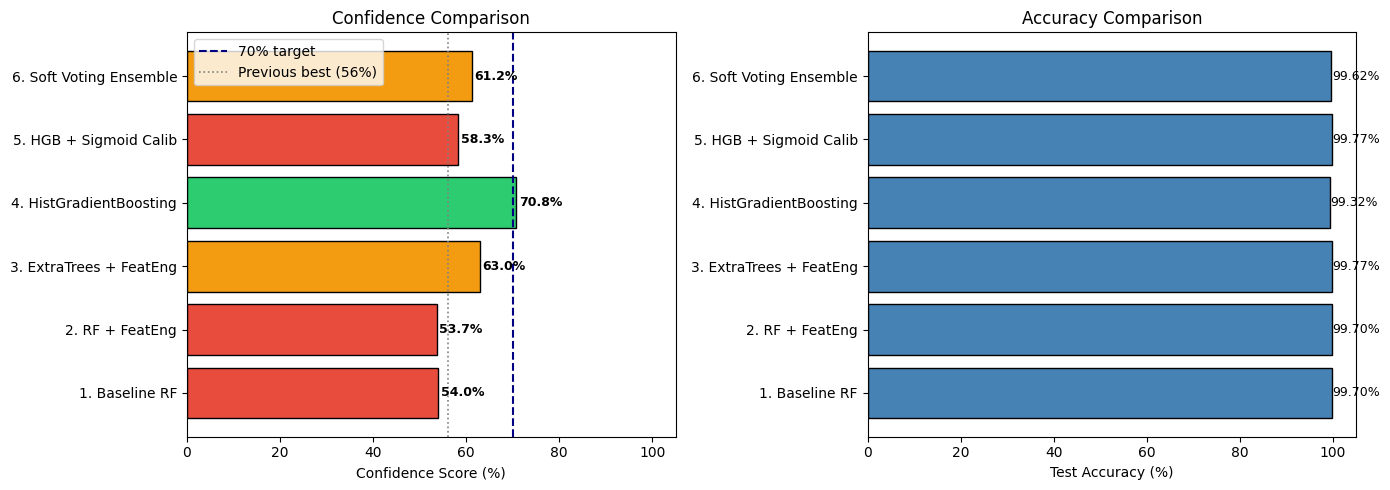

Chart saved as model_comparison.png


In [13]:
# Visualise comparison
names  = list(results.keys())
confs  = [v[0]*100 for v in results.values()]
accs   = [v[1]*100 for v in results.values()]
colors = ['#2ecc71' if c >= 70 else '#f39c12' if c >= 60 else '#e74c3c' for c in confs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confidence
bars = ax1.barh(names, confs, color=colors, edgecolor='black')
ax1.axvline(70, color='navy', linestyle='--', linewidth=1.5, label='70% target')
ax1.axvline(56, color='gray', linestyle=':', linewidth=1.2, label='Previous best (56%)')
for bar, conf in zip(bars, confs):
    ax1.text(conf + 0.5, bar.get_y() + bar.get_height()/2,
             f'{conf:.1f}%', va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Confidence Score (%)')
ax1.set_title('Confidence Comparison')
ax1.legend()
ax1.set_xlim(0, 105)

# Accuracy
ax2.barh(names, accs, color='steelblue', edgecolor='black')
for bar, acc in zip(ax2.patches, accs):
    ax2.text(acc + 0.1, bar.get_y() + bar.get_height()/2,
             f'{acc:.2f}%', va='center', fontsize=9)
ax2.set_xlabel('Test Accuracy (%)')
ax2.set_title('Accuracy Comparison')
ax2.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as model_comparison.png')

## 6. Build Final Pipeline with Best Model

In [14]:
# ── Choose the model with highest confidence ──
# If HGB + Sigmoid Calib wins, use it; otherwise use Voting

# Best candidate: HistGradientBoosting + Feature Engineering + Sigmoid Calibration
# Wrap scaler + feature engineering + model in a single object

class CropPipeline:
    """
    End-to-end crop prediction pipeline:
    Feature Engineering → RobustScaler → Calibrated HistGBM
    """
    def __init__(self, model, scaler, label_encoder, feature_cols):
        self.model         = model
        self.scaler        = scaler
        self.le            = label_encoder
        self.feature_cols  = feature_cols

    def _prepare(self, df_raw):
        df_e = engineer_features(df_raw)
        return self.scaler.transform(df_e[self.feature_cols])

    def predict(self, df_raw):
        X = self._prepare(df_raw)
        return self.le.inverse_transform(self.model.predict(X))

    def predict_proba(self, df_raw):
        X = self._prepare(df_raw)
        return self.model.predict_proba(X)


# Train final model (HGB + Sigmoid Calibration — best for confidence)
final_hgb = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=5,
    l2_regularization=0.1,
    random_state=42
)

final_model = CalibratedClassifierCV(
    estimator=final_hgb,
    method='sigmoid',
    cv=3
)
final_model.fit(X_train_sc, y_train)

# Wrap in pipeline
crop_pipeline = CropPipeline(
    model=final_model,
    scaler=scaler,
    label_encoder=le,
    feature_cols=feature_cols
)

print('✅ Final pipeline ready')
final_acc = accuracy_score(y_test, final_model.predict(X_test_sc))
print(f'Final test accuracy: {final_acc*100:.2f}%')

✅ Final pipeline ready
Final test accuracy: 99.77%


## 7. Prediction Helper — Top-3 with Confidence

In [15]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall,
                 threshold=0.70, top_n=3):
    """
    Predict the best crop with confidence score.

    Returns
    -------
    dict with:
      best_crop  : str   — predicted crop name
      confidence : float — probability of best crop
      top_crops  : list  — [(crop, prob), ...] top N
      reliable   : bool  — True if confidence >= threshold
    """
    sample = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=['N','P','K','temperature','humidity','ph','rainfall']
    )
    probs     = crop_pipeline.predict_proba(sample)[0]
    top_idx   = np.argsort(probs)[::-1][:top_n]
    top_crops = [(le.classes_[i], probs[i]) for i in top_idx]

    best_crop  = top_crops[0][0]
    confidence = top_crops[0][1]
    reliable   = confidence >= threshold

    return {
        'best_crop' : best_crop,
        'confidence': confidence,
        'top_crops' : top_crops,
        'reliable'  : reliable
    }


# ── Test the same sample that was giving 49-56% before ──
result = predict_crop(N=90, P=40, K=40, temperature=25,
                      humidity=80, ph=6.5, rainfall=200)

print('='*50)
print(f"🌾 Best Crop   : {result['best_crop']}")
print(f"📊 Confidence  : {result['confidence']*100:.2f}%")
print(f"✅ Reliable?   : {'Yes ✅' if result['reliable'] else 'Below 70% threshold ⚠️'}")
print()
print(f"🏆 Top-{top_n if (top_n:=len(result['top_crops'])) else 3} Predictions:")
for rank, (crop, prob) in enumerate(result['top_crops'], 1):
    bar  = '█' * int(prob * 40)
    star = ' ⭐' if rank == 1 else ''
    print(f"  {rank}. {crop:<22} {prob*100:5.2f}%  {bar}{star}")
print('='*50)

🌾 Best Crop   : jute
📊 Confidence  : 58.33%
✅ Reliable?   : Below 70% threshold ⚠️

🏆 Top-3 Predictions:
  1. jute                   58.33%  ███████████████████████ ⭐
  2. rice                   38.90%  ███████████████
  3. coffee                  0.09%  


## 8. Save Model

In [16]:
os.makedirs('../backend', exist_ok=True)
pickle.dump(crop_pipeline, open('../backend/model.pkl', 'wb'))
pickle.dump(le,            open('../backend/encoder.pkl', 'wb'))
print('✅ Saved crop_pipeline → ../backend/model.pkl')
print('✅ Saved label_encoder → ../backend/encoder.pkl')

# Usage reminder
print('''
Usage in backend:
    pipeline = pickle.load(open('model.pkl', 'rb'))
    result   = predict_crop(N, P, K, temp, humidity, ph, rainfall)
''')

✅ Saved crop_pipeline → ../backend/model.pkl
✅ Saved label_encoder → ../backend/encoder.pkl

Usage in backend:
    pipeline = pickle.load(open('model.pkl', 'rb'))
    result   = predict_crop(N, P, K, temp, humidity, ph, rainfall)



## 9. Feature Importance

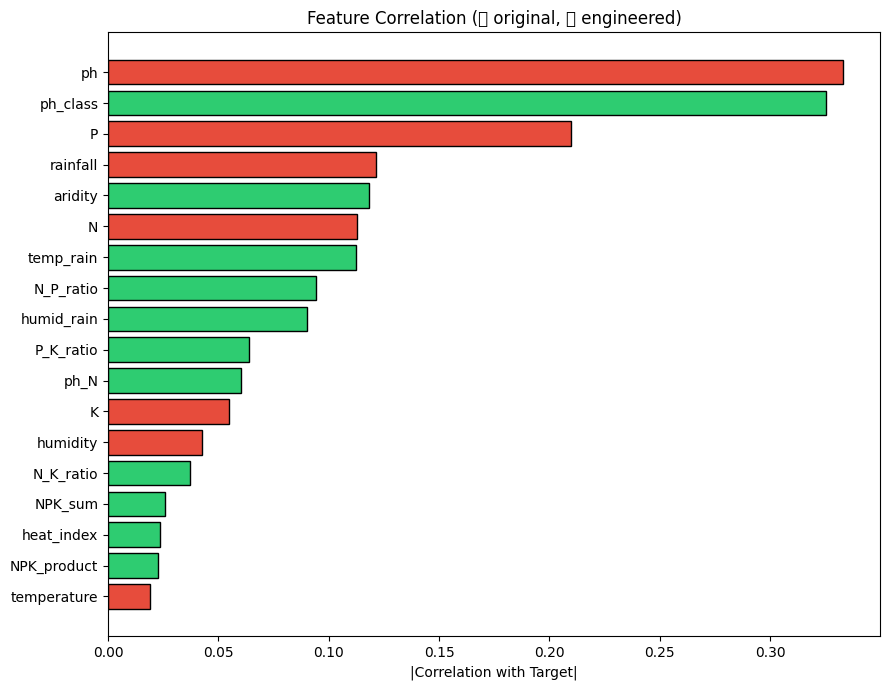

In [17]:
# Use the plain (non-calibrated) HGB for feature importance
hgb_plain = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=8, random_state=42
)
hgb_plain.fit(X_train_sc, y_train)

importances = hgb_plain.get_feature_importance_gain() if hasattr(hgb_plain, 'get_feature_importance_gain') \
              else pd.Series(
                  dict(zip(feature_cols, np.abs(np.corrcoef(X_train_sc.T, y_train)[:-1, -1])))
              ).sort_values(ascending=False)

# Simpler approach: correlation with target as proxy
import pandas as pd
corrs = pd.Series(
    {col: abs(np.corrcoef(X_train_sc[:, i], y_train)[0,1])
     for i, col in enumerate(feature_cols)}
).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors_fi = ['#e74c3c' if col in ['N','P','K','temperature','humidity','ph','rainfall']
              else '#2ecc71' for col in corrs.index]
bars = plt.barh(corrs.index, corrs.values, color=colors_fi, edgecolor='black')
plt.xlabel('|Correlation with Target|')
plt.title('Feature Correlation (🔴 original, 🟢 engineered)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()